In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base = '/content/drive/MyDrive/IDS_Africa_ML/'
folders = ['data', 'notebooks', 'models', 'figures', 'outputs']

for folder in folders:
    os.makedirs(base + folder, exist_ok=True)


In [3]:
!pip install shap imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
data_path = base + 'data/'

# List all CSV files found
files = [f for f in os.listdir(data_path) if f.endswith('.csv')]
print(f"Found {len(files)} CSV files:")
for f in sorted(files):
    print(f"  - {f}")

Found 8 CSV files:
  - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  - Friday-WorkingHours-Morning.pcap_ISCX.csv
  - Monday-WorkingHours.pcap_ISCX.csv
  - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
  - Wednesday-workingHours.pcap_ISCX.csv


In [5]:
dfs = []
for f in sorted(files):
    temp = pd.read_csv(data_path + f, encoding='latin-1', low_memory=False)
    print(f"Loaded: {f} → {temp.shape[0]:,} rows")
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Clean column names (known CICIDS-2017 issue)
df.columns = df.columns.str.strip()

print(f"\n Combined dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv → 225,745 rows
Loaded: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv → 286,467 rows
Loaded: Friday-WorkingHours-Morning.pcap_ISCX.csv → 191,033 rows
Loaded: Monday-WorkingHours.pcap_ISCX.csv → 529,918 rows
Loaded: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv → 288,602 rows
Loaded: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv → 170,366 rows
Loaded: Tuesday-WorkingHours.pcap_ISCX.csv → 445,909 rows
Loaded: Wednesday-workingHours.pcap_ISCX.csv → 692,703 rows

 Combined dataset: 2,830,743 rows × 79 columns


In [7]:
# print("=" * 55)
print("DATASET OVERVIEW")
# print("=" * 55)
print(f"\nTotal records   : {df.shape[0]:,}")
print(f"Total features  : {df.shape[1] - 1}")
print(f"Attack classes  : {df['Label'].nunique()}")
print(f"\nClass distribution:")
print("-" * 40)
print(df['Label'].value_counts().to_string())
print(f"\nMissing values  : {df.isnull().sum().sum():,}")
print(f"Infinite values : {np.isinf(df.select_dtypes(include=np.number)).sum().sum():,}")

DATASET OVERVIEW

Total records   : 2,830,743
Total features  : 78
Attack classes  : 15

Class distribution:
----------------------------------------
Label
BENIGN                          2273097
DoS Hulk                         231073
PortScan                         158930
DDoS                             128027
DoS GoldenEye                     10293
FTP-Patator                        7938
SSH-Patator                        5897
DoS slowloris                      5796
DoS Slowhttptest                   5499
Bot                                1966
Web Attack ï¿½ Brute Force         1507
Web Attack ï¿½ XSS                  652
Infiltration                         36
Web Attack ï¿½ Sql Injection         21
Heartbleed                           11

Missing values  : 1,358
Infinite values : 4,376


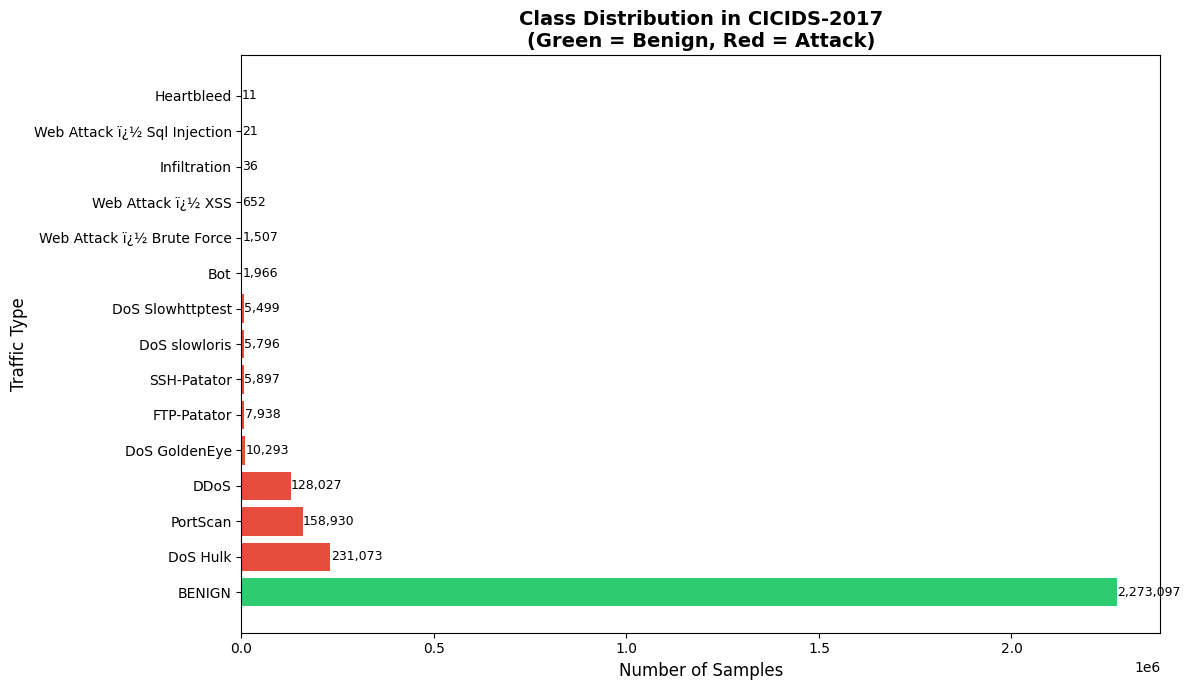

Figure saved to Drive


In [8]:
plt.figure(figsize=(12, 7))

counts = df['Label'].value_counts()
colors = ['#2ecc71' if x == 'BENIGN' else '#e74c3c' for x in counts.index]

bars = plt.barh(counts.index, counts.values, color=colors)
plt.xlabel('Number of Samples', fontsize=12)
plt.ylabel('Traffic Type', fontsize=12)
plt.title('Class Distribution in CICIDS-2017\n(Green = Benign, Red = Attack)',
          fontsize=14, fontweight='bold')

# Add value labels on bars
for bar, val in zip(bars, counts.values):
    plt.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(base + 'figures/01_class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to Drive")

In [9]:
# This cell is YOUR RESEARCH NOTES
# These sentences become your Methodology section

notes = """
EXPLORATION FINDINGS — 07/04/2026
======================================

1. Total samples     : 2,830,743
2. Total features    : 78 network traffic features
3. Attack classes    : 15
4. Majority class    : BENIGN (80.3% of data) — severe imbalance present
5. Rarest class      : Heartbleed — only 11 samples
6. Imbalance ratio   : approximately 11:2273097 (benign to rarest attack)
7. Missing values    : 1358
8. Infinite values   : 4376 — must be handled in preprocessing

KEY INSIGHT:
The severe class imbalance confirms that standard accuracy metrics will be
misleading. F1-score and per-class recall must be the primary evaluation
metrics. SMOTE resampling will be applied in the preprocessing phase.
"""

print(notes)

# Save notes
with open(base + 'outputs/exploration_notes.txt', 'w') as f:
    f.write(notes)

print("Notes saved")


EXPLORATION FINDINGS — 07/04/2026

1. Total samples     : 2,830,743
2. Total features    : 78 network traffic features
3. Attack classes    : 15
4. Majority class    : BENIGN (80.3% of data) — severe imbalance present
5. Rarest class      : Heartbleed — only 11 samples
6. Imbalance ratio   : approximately 11:2273097 (benign to rarest attack)
7. Missing values    : 1358
8. Infinite values   : 4376 — must be handled in preprocessing

KEY INSIGHT:
The severe class imbalance confirms that standard accuracy metrics will be
misleading. F1-score and per-class recall must be the primary evaluation
metrics. SMOTE resampling will be applied in the preprocessing phase.

Notes saved
